In [1]:
# project 1st file 기본 전처리(robustScaler) 후 모델 돌려보기 2025.11.26
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os

import importlib
from utils import modeling
importlib.reload(modeling)

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 
import utils.modeling      as mo 

In [3]:
results = {}
results['XGB_robustScaler_HO'] = {'AUC': 0.9645, '정확도': 0.9996, '정밀도': 0.9310, '재현율': 0.8265, 'F1': 0.8757}
results['XGB_robustScaler_HO_smote'] = {'AUC': 0.9757, '정확도': 0.9991, '정밀도': 0.6983, '재현율': 0.8265, 'F1': 0.7570}
results['XGB_robustScaler_HO_under'] = {'AUC': 0.9725, '정확도': 0.9402, '정밀도': 0.0255, '재현율': 0.9082, 'F1': 0.0497}
results['XGB_robustScaler_HO_combined'] = {'AUC': 0.9757, '정확도': 0.9991, '정밀도': 0.6983, '재현율': 0.8265, 'F1': 0.7570}

results['GB_robustScaler_HO'] = {'AUC': 0.2959, '정확도': 0.9985, '정밀도': 0.7308, '재현율': 0.1939, 'F1': 0.3065}
results['GB_robustScaler_HO_smote'] = {'AUC': 0.9750, '정확도': 0.9874, '정밀도': 0.1094, '재현율': 0.8878, 'F1': 0.1948}
results['GB_robustScaler_HO_under'] = {'AUC': 0.9715, '정확도': 0.9597, '정밀도': 0.0367, '재현율': 0.8878, 'F1': 0.0705}
results['GB_robustScaler_HO_combined'] = {'AUC': 0.9750, '정확도': 0.9874, '정밀도': 0.1094, '재현율': 0.8878, 'F1': 0.1948}

results['DT_robustScaler_HO'] = {'AUC': 0.8926, '정확도': 0.9992, '정밀도': 0.7549, '재현율': 0.7857, 'F1': 0.7700}
results['DT_robustScaler_HO_smote'] = {'AUC': 0.8714, '정확도': 0.9974, '정밀도': 0.3744, '재현율': 0.7449, 'F1': 0.4983}
results['DT_robustScaler_HO_under'] = {'AUC': 0.9125, '정확도': 0.9169, '정밀도': 0.0185, '재현율': 0.9082, 'F1': 0.0362}
results['DT_robustScaler_HO_combined'] = {'AUC': 0.8714, '정확도': 0.9974, '정밀도': 0.3744, '재현율': 0.7449, 'F1': 0.4983}

results['mlp_robustScaler_HO'] = { 'AUC': 0.9652, '정확도': 0.9995, '정밀도': 0.9080, '재현율': 0.8061, 'F1': 0.8541}
results['mlp_robustScaler_HO_smote'] = {'AUC': 0.9663, '정확도': 0.9991, '정밀도': 0.7182, '재현율': 0.8061, 'F1': 0.7596 }
results['mlp_robustScaler_HO_under'] = {'AUC': 0.9719, '정확도': 0.9682, '정밀도': 0.0461, '재현율': 0.8878, 'F1': 0.0877 }
results['mlp_robustScaler_HO_combined'] = {'AUC': 0.9663, '정확도': 0.9991, '정밀도': 0.7182, '재현율': 0.8061, 'F1': 0.7596 }

results['lr_robustScaler_HO'] = {'AUC': 0.9605, '정확도': 0.9764, '정밀도': 0.0613, '재현율': 0.8878, 'F1': 0.1147}
results['lr_robustScaler_HO_smote'] = {'AUC': 0.9601, '정확도': 0.9754, '정밀도': 0.0583, '재현율': 0.8776, 'F1': 0.1093 }
results['lr_robustScaler_HO_under'] = {'AUC': 0.9689, '정확도': 0.9838, '정밀도': 0.0862, '재현율': 0.8776, 'F1': 0.1569 }
results['lr_robustScaler_HO_combined'] = {'AUC': 0.9601, '정확도': 0.9754, '정밀도': 0.0583, '재현율': 0.8776, 'F1': 0.1093 }

In [ ]:
df_results = pd.DataFrame(results).T


In [11]:
df_results.to_csv('../results/robustScaler_Results.txt')
df_results

,AUC,정확도,정밀도,재현율,F1
XGB_robustScaler_HO,0.9645,0.9996,0.9310,0.8265,0.8757
XGB_robustScaler_HO_smote,0.9757,0.9991,0.6983,0.8265,0.7570
XGB_robustScaler_HO_under,0.9725,0.9402,0.0255,0.9082,0.0497
XGB_robustScaler_HO_combined,0.9757,0.9991,0.6983,0.8265,0.7570
GB_robustScaler_HO,0.2959,0.9985,0.7308,0.1939,0.3065
GB_robustScaler_HO_smote,0.9750,0.9874,0.1094,0.8878,0.1948
GB_robustScaler_HO_under,0.9715,0.9597,0.0367,0.8878,0.0705
GB_robustScaler_HO_combined,0.9750,0.9874,0.1094,0.8878,0.1948
DT_robustScaler_HO,0.8926,0.9992,0.7549,0.7857,0.7700
DT_robustScaler_HO_smote,0.8714,0.9974,0.3744,0.7449,0.4983


In [ ]:
# mo.plot_sampling_metrics(results, 'RobustScaler Results Each Models')

KeyError: 'R'

<Figure size 1000x600 with 0 Axes>

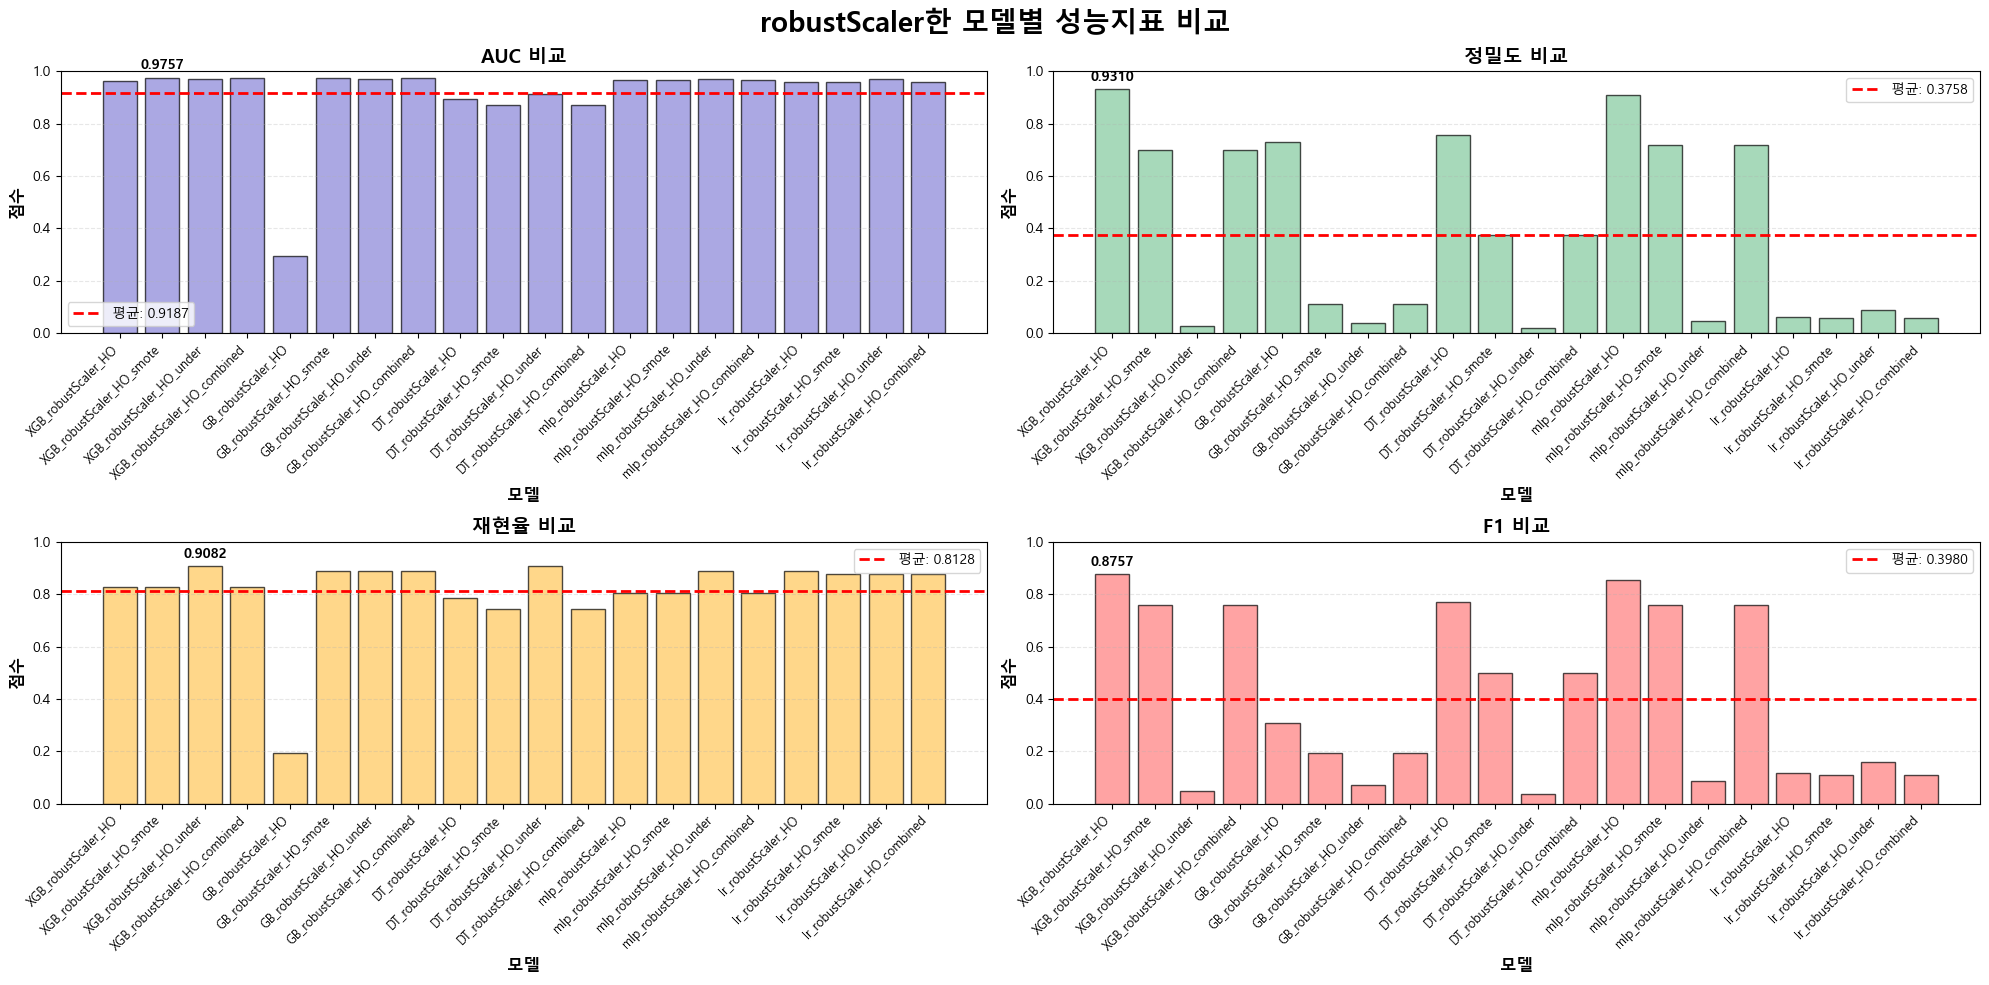


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9757 (XGB_robustScaler_HO_smote)
  최저: 0.2959 (GB_robustScaler_HO)
  평균: 0.9187
  표준편차: 0.1506

[정밀도]
  최고: 0.9310 (XGB_robustScaler_HO)
  최저: 0.0185 (DT_robustScaler_HO_under)
  평균: 0.3758
  표준편차: 0.3482

[재현율]
  최고: 0.9082 (XGB_robustScaler_HO_under)
  최저: 0.1939 (GB_robustScaler_HO)
  평균: 0.8128
  표준편차: 0.1543

[F1]
  최고: 0.8757 (XGB_robustScaler_HO)
  최저: 0.0362 (DT_robustScaler_HO_under)
  평균: 0.3980
  표준편차: 0.3217


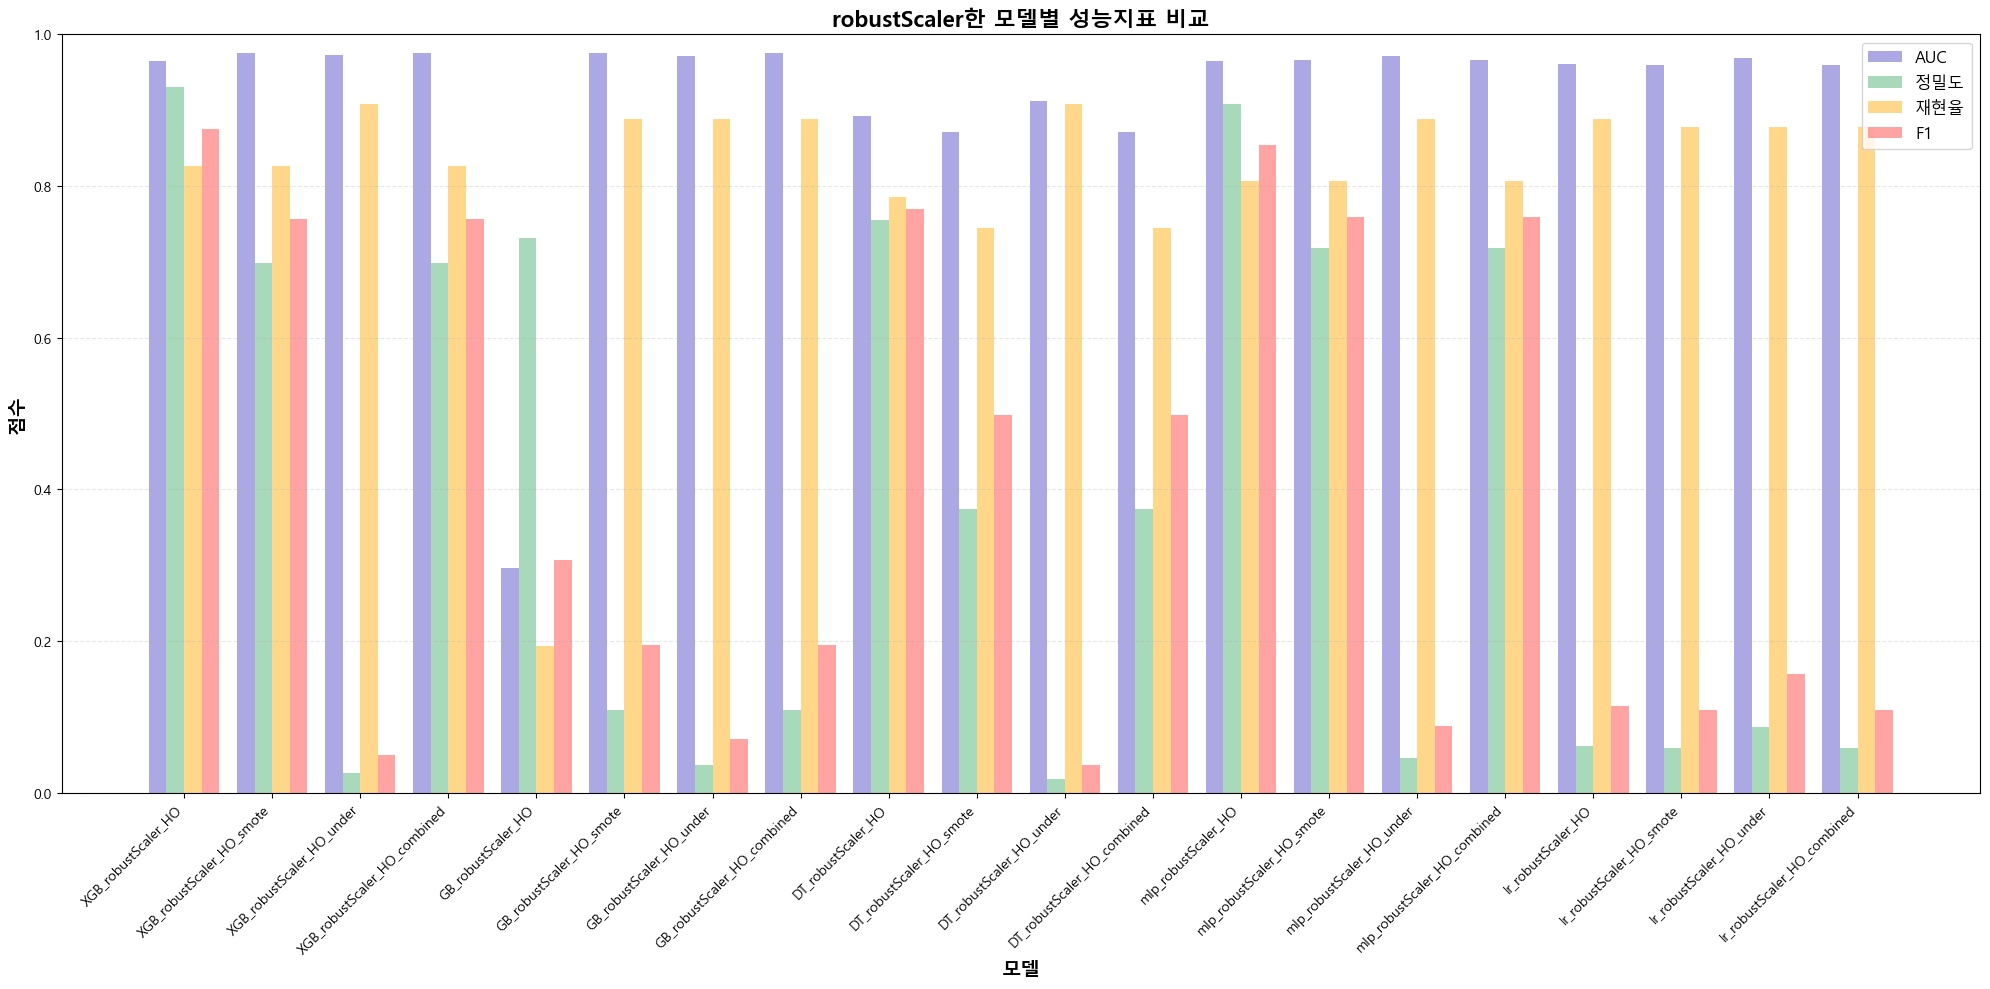


=== F1 Score 기준 상위 5개 모델 ===
                                 AUC     정밀도     재현율      F1
XGB_robustScaler_HO           0.9645  0.9310  0.8265  0.8757
mlp_robustScaler_HO           0.9652  0.9080  0.8061  0.8541
DT_robustScaler_HO            0.8926  0.7549  0.7857  0.7700
mlp_robustScaler_HO_smote     0.9663  0.7182  0.8061  0.7596
mlp_robustScaler_HO_combined  0.9663  0.7182  0.8061  0.7596

그래프가 저장되었습니다: ../images/robustScaler한_모델별_성능지표_비교_2025_1127.png


In [21]:
mo.model_metrics_graph(results, 'robustScaler한 모델별 성능지표 비교')